In [ ]:
# ============================================
# CHANGE THESE TWO LINES
# ============================================
GITHUB_USER = 'skm48'
REPO_NAME   = 'MINI_PROJECT'

import os

if not os.path.exists(f'/{REPO_NAME}'):
    # First time — clone
    !git clone https://github.com/Skm48/MINI_PROJECT.git
    print('Repo cloned!')
else:
    # Already cloned — pull latest
    !cd /content/{REPO_NAME} && git pull
    print('Pulled latest changes!')

os.chdir(f'/content/{REPO_NAME}')
print(f'Working directory: {os.getcwd()}')

Cloning into 'MINI_PROJECT'...
remote: Enumerating objects: 224, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 224 (delta 9), reused 19 (delta 7), pack-reused 202 (from 1)
Receiving objects: 100% (224/224), 328.98 MiB | 19.82 MiB/s, done.
Resolving deltas: 100% (90/90), done.
Updating files: 100% (62/62), done.
Repo cloned!
Working directory: /content/MINI_PROJECT


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/Collab\ Files/Dataset.zip /content/MINI_PROJECT/data/
!unzip -q /content/MINI_PROJECT/data/Dataset.zip -d /content/MINI_PROJECT/data/

In [ ]:
# Remove the Mac junk folder and nested duplicate
!rm -rf /content/MINI_PROJECT/data/chest_xray/__MACOSX
!rm -rf /content/MINI_PROJECT/data/chest_xray/chest_xray

# Check it's clean
!ls /content/MINI_PROJECT/data/chest_xray

test  train  val


In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from pathlib import Path

import torch
from torchvision import transforms

from src.utils import set_seed, get_device, load_config
from src.dataset import (
    collect_image_paths,
    stratified_split,
    get_transforms,
    get_dataloaders,
    compute_class_weights,
)

set_seed(42)
device = get_device()
config = load_config()

print('All imports ready')

Using GPU: Tesla T4
All imports ready


In [ ]:
# Build everything in one call
loaders = get_dataloaders(config)

Total images found: 5856
  By original split: {'train': np.int64(5216), 'test': np.int64(624), 'val': np.int64(16)}
  By label: {1: np.int64(4273), 0: np.int64(1583)}

Merged train+val: 5232 images
Original test kept: 624 images

New split sizes:
  Train: 4650  (Normal: 1199, Pneumonia: 3451)
  Val:   582  (Normal: 150, Pneumonia: 432)
  Test:  624  (Normal: 234, Pneumonia: 390)

Split indices saved to: data/split_indices.csv

Class weights: Normal=1.939, Pneumonia=0.674

DataLoaders ready:
  Train: 146 batches (4650 images)
  Val:   19 batches (582 images)
  Test:  20 batches (624 images)


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# VGG16
vgg16 = models.vgg16(weights='IMAGENET1K_V1')
vgg16.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2),
)
vgg16.load_state_dict(torch.load('model/checkpoints/vgg16_best.pth', map_location=device))
vgg16 = vgg16.to(device)
vgg16.eval()

# ResNet50
resnet50 = models.resnet50(weights='IMAGENET1K_V1')
resnet50.fc = nn.Sequential(
    nn.Linear(2048, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2),
)
resnet50.load_state_dict(torch.load('model/checkpoints/resnet50_best.pth', map_location=device))
resnet50 = resnet50.to(device)
resnet50.eval()

# EfficientNet-B0
efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
efficientnet.classifier = nn.Sequential(
    nn.Linear(1280, 256),   # index 0
    nn.ReLU(),               # index 1
    nn.Dropout(0.5),         # index 2
    nn.Linear(256, 2),       # index 3
)
efficientnet.load_state_dict(torch.load('model/checkpoints/efficientnet_b0_best.pth', map_location=device))
efficientnet = efficientnet.to(device)
efficientnet.eval()

print("All 3 models loaded")

All 3 models loaded


In [ ]:
import numpy as np
from tqdm import tqdm

def extract_features(model, model_name, loader, device):
    """Extract features from the layer before the classifier."""
    features = []
    labels_list = []

    # Hook to capture features
    feature_output = {}

    if model_name == 'vgg16':
        # Features come from avgpool (after conv blocks, before classifier)
        hook = model.avgpool.register_forward_hook(
            lambda m, inp, out: feature_output.update({'feat': out})
        )
    elif model_name == 'resnet50':
        hook = model.avgpool.register_forward_hook(
            lambda m, inp, out: feature_output.update({'feat': out})
        )
    elif model_name == 'efficientnet':
        hook = model.avgpool.register_forward_hook(
            lambda m, inp, out: feature_output.update({'feat': out})
        )

    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Extracting {model_name}"):
            images = images.to(device)
            _ = model(images)  # forward pass triggers the hook

            feat = feature_output['feat'].squeeze()  # remove spatial dims
            if feat.dim() == 1:
                feat = feat.unsqueeze(0)
            features.append(feat.cpu().numpy())
            labels_list.extend(labels.numpy())

    hook.remove()
    features = np.concatenate(features, axis=0)
    labels_arr = np.array(labels_list)
    print(f"{model_name} features shape: {features.shape}")
    return features, labels_arr

In [ ]:
# Train features
vgg_train_feat, train_labels = extract_features(vgg16, 'vgg16', loaders['train'], device)
res_train_feat, _ = extract_features(resnet50, 'resnet50', loaders['train'], device)
eff_train_feat, _ = extract_features(efficientnet, 'efficientnet', loaders['train'], device)

# Val features
vgg_val_feat, val_labels = extract_features(vgg16, 'vgg16', loaders['val'], device)
res_val_feat, _ = extract_features(resnet50, 'resnet50', loaders['val'], device)
eff_val_feat, _ = extract_features(efficientnet, 'efficientnet', loaders['val'], device)

# Test features
vgg_test_feat, test_labels = extract_features(vgg16, 'vgg16', loaders['test'], device)
res_test_feat, _ = extract_features(resnet50, 'resnet50', loaders['test'], device)
eff_test_feat, _ = extract_features(efficientnet, 'efficientnet', loaders['test'], device)

# Flatten VGG16 features from (4650, 512, 7, 7) to (4650, 25088)
vgg_train_feat = vgg_train_feat.reshape(vgg_train_feat.shape[0], -1)
vgg_val_feat = vgg_val_feat.reshape(vgg_val_feat.shape[0], -1)
vgg_test_feat = vgg_test_feat.reshape(vgg_test_feat.shape[0], -1)

print(f"VGG16 flattened: {vgg_train_feat.shape}")

# Now concatenate
train_fused = np.concatenate([vgg_train_feat, res_train_feat, eff_train_feat], axis=1)
val_fused = np.concatenate([vgg_val_feat, res_val_feat, eff_val_feat], axis=1)
test_fused = np.concatenate([vgg_test_feat, res_test_feat, eff_test_feat], axis=1)

print(f"\nFused feature sizes:")
print(f"  Train: {train_fused.shape}")
print(f"  Val:   {val_fused.shape}")
print(f"  Test:  {test_fused.shape}")

print(f"\nFused feature sizes:")
print(f"  Train: {train_fused.shape}")
print(f"  Val:   {val_fused.shape}")
print(f"  Test:  {test_fused.shape}")

Extracting vgg16: 100%|██████████| 146/146 [01:27<00:00,  1.67it/s]


vgg16 features shape: (4650, 512, 7, 7)


Extracting resnet50: 100%|██████████| 146/146 [01:21<00:00,  1.79it/s]


resnet50 features shape: (4650, 2048)


Extracting efficientnet: 100%|██████████| 146/146 [01:18<00:00,  1.87it/s]


...

vgg16 features shape: (624, 512, 7, 7)


Extracting resnet50: 100%|██████████| 20/20 [00:10<00:00,  1.98it/s]


resnet50 features shape: (624, 2048)


Extracting efficientnet: 100%|██████████| 20/20 [00:10<00:00,  1.98it/s]


efficientnet features shape: (624, 1280)
VGG16 flattened: (4650, 25088)

Fused feature sizes:
  Train: (4650, 28416)
  Val:   (582, 28416)
  Test:  (624, 28416)

Fused feature sizes:
  Train: (4650, 28416)
  Val:   (582, 28416)
  Test:  (624, 28416)


In [ ]:
# Average pool VGG16 features instead of flattening
vgg_train_feat = vgg_train_feat.reshape(-1, 512, 7, 7).mean(axis=(2, 3))  # (4650, 512)
vgg_val_feat = vgg_val_feat.reshape(-1, 512, 7, 7).mean(axis=(2, 3))
vgg_test_feat = vgg_test_feat.reshape(-1, 512, 7, 7).mean(axis=(2, 3))

print(f"VGG16 pooled: {vgg_train_feat.shape}")  # should be (4650, 512)

# Re-concatenate — now much smaller
train_fused = np.concatenate([vgg_train_feat, res_train_feat, eff_train_feat], axis=1)
val_fused = np.concatenate([vgg_val_feat, res_val_feat, eff_val_feat], axis=1)
test_fused = np.concatenate([vgg_test_feat, res_test_feat, eff_test_feat], axis=1)

print(f"New fused size: {train_fused.shape}")  # should be (4650, 3840)

VGG16 pooled: (4650, 512)
New fused size: (4650, 3840)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
train_dataset = TensorDataset(
    torch.FloatTensor(train_fused),
    torch.LongTensor(train_labels)
)
val_dataset = TensorDataset(
    torch.FloatTensor(val_fused),
    torch.LongTensor(val_labels)
)
test_dataset = TensorDataset(
    torch.FloatTensor(test_fused),
    torch.LongTensor(test_labels)
)

fusion_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
fusion_val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
fusion_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Fusion classifier
input_size = train_fused.shape[1]  # 28416

fusion_model = nn.Sequential(
    nn.Linear(input_size, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2),
).to(device)

print(f"Fusion input size: {input_size}")
print(f"Fusion model:\n{fusion_model}")

Fusion input size: 3840
Fusion model:
Sequential(
  (0): Linear(in_features=3840, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=128, out_features=2, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss(weight=loaders['class_weights'].to(device))
optimizer = torch.optim.Adam(fusion_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

num_epochs = 20
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # Train
    fusion_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for features, labels in fusion_train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = fusion_model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validate
    fusion_model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for features, labels in fusion_val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = fusion_model(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(fusion_model.state_dict(), 'models/checkpoints/fusion_best.pth')

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 1: train_loss=0.4934 train_acc=0.7572 | val_loss=0.3532 val_acc=0.8299
Epoch 2: train_loss=0.2953 train_acc=0.8770 | val_loss=0.2972 val_acc=0.8093
Epoch 3: train_loss=0.2303 train_acc=0.9084 | val_loss=0.2251 val_acc=0.8643
Epoch 4: train_loss=0.2142 train_acc=0.9099 | val_loss=0.3129 val_acc=0.7973
Epoch 5: train_loss=0.2053 train_acc=0.9181 | val_loss=0.2040 val_acc=0.8711
Epoch 6: train_loss=0.1972 train_acc=0.9185 | val_loss=0.1544 val_acc=0.9227
Epoch 7: train_loss=0.1670 train_acc=0.9333 | val_loss=0.2120 val_acc=0.8694
Epoch 8: train_loss=0.1723 train_acc=0.9219 | val_loss=0.2004 val_acc=0.8677
Epoch 9: train_loss=0.1655 train_acc=0.9310 | val_loss=0.1551 val_acc=0.9107
Epoch 10: train_loss=0.1604 train_acc=0.9327 | val_loss=0.1559 val_acc=0.9141
Epoch 11: train_loss=0.1008 train_acc=0.9591 | val_loss=0.1815 val_acc=0.9021
Epoch 12: train_loss=0.0895 train_acc=0.9628 | val_loss=0.2422 val_acc=0.8625
Epoch 13: train_loss=0.0818 train_acc=0.9671 | val_loss=0.2654 val_acc=0.

              precision    recall  f1-score   support

      Normal       0.89      0.80      0.84       234
   Pneumonia       0.89      0.94      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.87      0.88       624
weighted avg       0.89      0.89      0.89       624

Accuracy:  0.8878
F1 Score:  0.8866
AUC-ROC:   0.9461


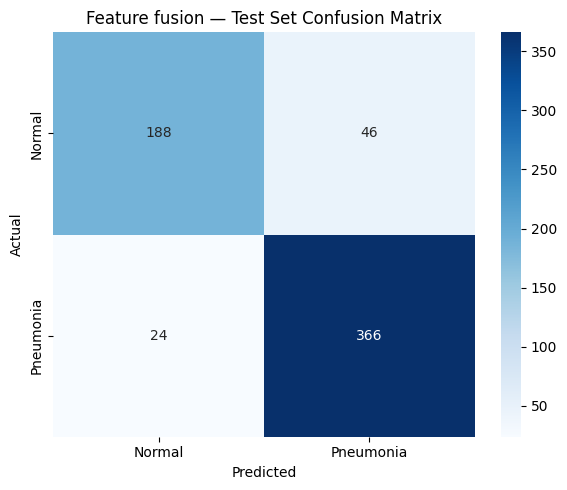


True Negatives (Normal correctly):   188
False Positives (Normal → Pneumonia): 46
False Negatives (Pneumonia → Normal): 24
True Positives (Pneumonia correctly): 366


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


fusion_model.load_state_dict(torch.load('models/checkpoints/fusion_best.pth', map_location=device))
fusion_model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for features, labels in fusion_test_loader:
        features = features.to(device)
        outputs = fusion_model(features)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

accuracy = sum(1 for a, b in zip(all_labels, all_preds) if a == b) / len(all_labels)
f1 = f1_score(all_labels, all_preds, average='weighted')
auc = roc_auc_score(all_labels, all_probs)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Feature fusion — Test Set Confusion Matrix')
plt.tight_layout()
plt.savefig('outputs/figures/fusion_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print what the confusion matrix means
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (Normal correctly):   {tn}")
print(f"False Positives (Normal → Pneumonia): {fp}")
print(f"False Negatives (Pneumonia → Normal): {fn}")
print(f"True Positives (Pneumonia correctly): {tp}")

In [ ]:
!cd /content/MINI_PROJECT && git config user.name "Skm48"
!cd /content/MINI_PROJECT && git config user.email "skm48@student.le.ac.uk"

In [33]:
!cd /content/MINI_PROJECT && git remote set-url origin https://Skm48@github.com/Skm48/MINI_PROJECT.git


In [32]:
!cp /content/drive/My\ Drive/Colab\ Notebooks/05_Model_Fusion_Feature.ipynb /content/MINI_PROJECT/notebooks/